## Understanding Campus Energy Consumption

This notebook provides an initial exploration of the provided datasets. The goal is to understand patterns, relationships, and prepare the data for further modelling.

In [9]:
# Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Read CSV files
calendar = pd.read_csv("data/Academic Calendar.csv")
electricity = pd.read_csv("data/Electricity Consumption Monthly.csv")
weather = pd.read_csv("data/Eric D. Soulis Weather Station.csv")
print("Calendar shape:", calendar.shape)
print("Electricity shape:", electricity.shape)
print("Weather shape:", weather.shape)

Calendar shape: (3653, 5)
Electricity shape: (2160, 4)
Weather shape: (87669, 10)


In [ ]:
# Convert date columns to datetime
calendar['Date'] = pd.to_datetime(calendar['Date'])
electricity['Start Date'] = pd.to_datetime(electricity['Start Date'])
electricity['End Date'] = pd.to_datetime(electricity['End Date'])
weather['DateTime'] = pd.to_datetime(weather[['Year', 'Month', 'Day', 'Hour']])
weather = weather.sort_values('DateTime').reset_index(drop=True)

# Set outliers to NaN based on plausible physical ranges
weather['Temperature'] = weather['Temperature'].where(
    (weather['Temperature'] >= -40) & (weather['Temperature'] <= 40), np.nan
)
weather['Solar - Incoming'] = weather['Solar - Incoming'].where(
    (weather['Solar - Incoming'] >= 0) & (weather['Solar - Incoming'] <= 1500), np.nan
)
weather['Wind Speed - Average 2.0'] = weather['Wind Speed - Average 2.0'].where(
    (weather['Wind Speed - Average 2.0'] >= 0) & (weather['Wind Speed - Average 2.0'] <= 50), np.nan
)
weather['Wind Speed - Gust 2.0'] = weather['Wind Speed - Gust 2.0'].where(
    (weather['Wind Speed - Gust 2.0'] >= 0) & (weather['Wind Speed - Gust 2.0'] <= 70), np.nan
)
weather['Wind Direction'] = weather['Wind Direction'].where(
    (weather['Wind Direction'] >= 0) & (weather['Wind Direction'] <= 360), np.nan
)
weather['RH'] = weather['RH'].where(
    (weather['RH'] >= 0) & (weather['RH'] <= 100), np.nan
)

# check for missing values
print("\n" + "="*50)
print("MISSING VALUES IN EACH DATASET")
print("="*50)
print("\n--- Academic Calendar ---")
print(calendar.isnull().sum())
print("\n--- Electricity Consumption ---")
print(electricity.isnull().sum())
print("\n--- Weather Station ---")
print(weather.isnull().sum())


MISSING VALUES IN EACH DATASET

--- Academic Calendar ---
Date                     0
Weekend                  0
Holiday                  0
Lecture Day              0
Lecture Days in Month    0
dtype: int64

--- Electricity Consumption ---
Start Date        0
End Date          0
Building Code     0
Consumption      68
dtype: int64

--- Weather Station ---
Year                            0
Month                           0
Day                             0
Hour                            0
Temperature                 13687
Solar - Incoming            14162
Wind Speed - Average 2.0    13973
Wind Speed - Gust 2.0       13852
Wind Direction              13935
RH                          14196
DateTime                        0
dtype: int64


Explore Academic Calendar

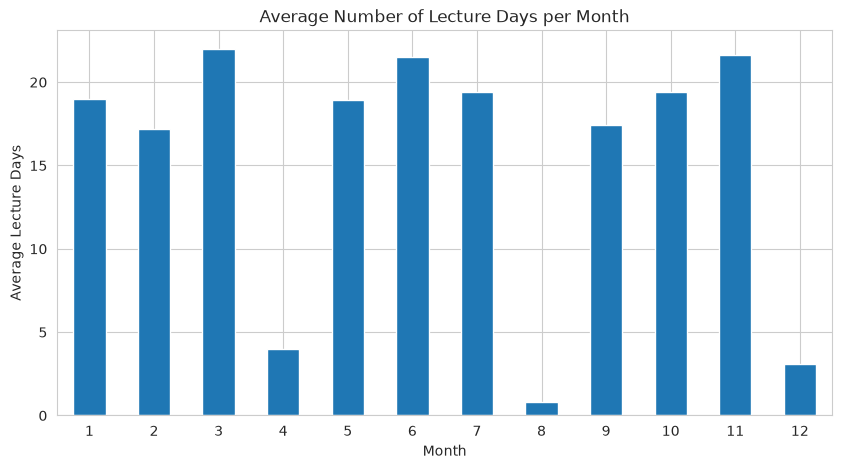

In [ ]:
calendar['Year'] = calendar['Date'].dt.year
calendar['Month'] = calendar['Date'].dt.month
calendar['DayOfWeek'] = calendar['Date'].dt.dayofweek  # Monday=0, Sunday=6

# Average lecture days per month
lecture_summary = calendar.groupby(['Year', 'Month'])['Lecture Day'].sum().reset_index()
avg_lecture_days = lecture_summary.groupby('Month')['Lecture Day'].mean()

plt.figure(figsize=(10,5))
avg_lecture_days.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Lecture Days')
plt.title('Average Number of Lecture Days per Month')
plt.xticks(rotation=0)
plt.show()

Explore Weather Data

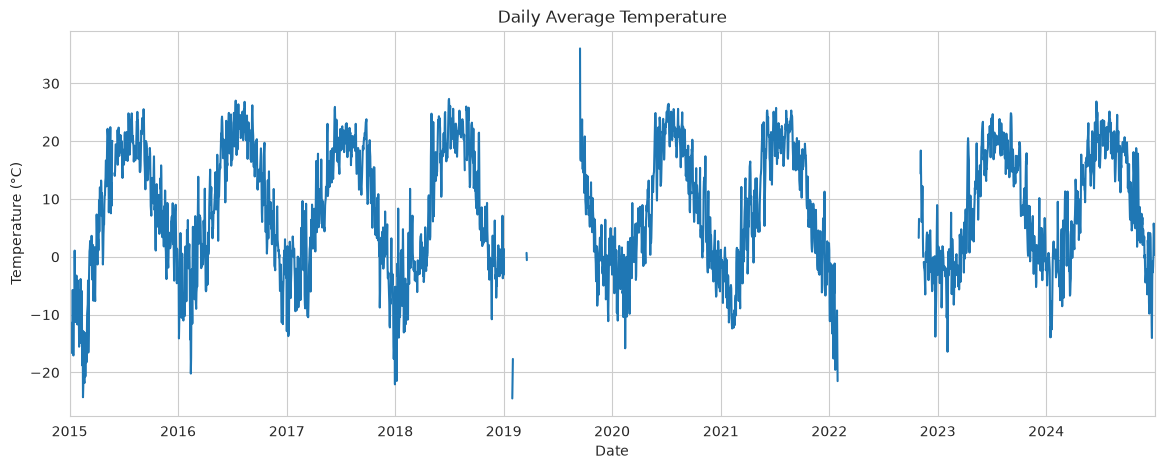

In [ ]:
weather_ts = weather.set_index('DateTime')
daily_temp = weather_ts['Temperature'].resample('D').mean()

# Daily average temperature
plt.figure(figsize=(14,5))
daily_temp.plot()
plt.title('Daily Average Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

Explore Electricity Consumption

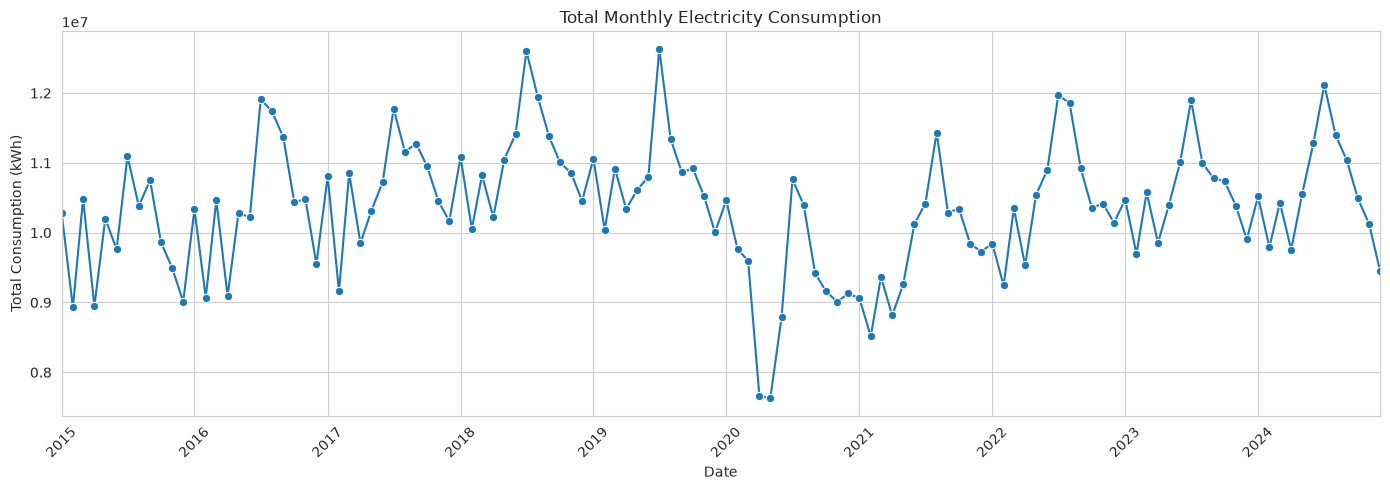

In [ ]:
electricity['Year'] = electricity['Start Date'].dt.year
electricity['Month'] = electricity['Start Date'].dt.month
total_monthly = electricity.groupby('Start Date')['Consumption'].sum().reset_index()

plt.figure(figsize=(14,5))
sns.lineplot(data=total_monthly, x='Start Date', y='Consumption', marker='o')
plt.title('Total Monthly Electricity Consumption')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.xticks(rotation=45)
plt.margins(x=0)
plt.tight_layout()
plt.show()

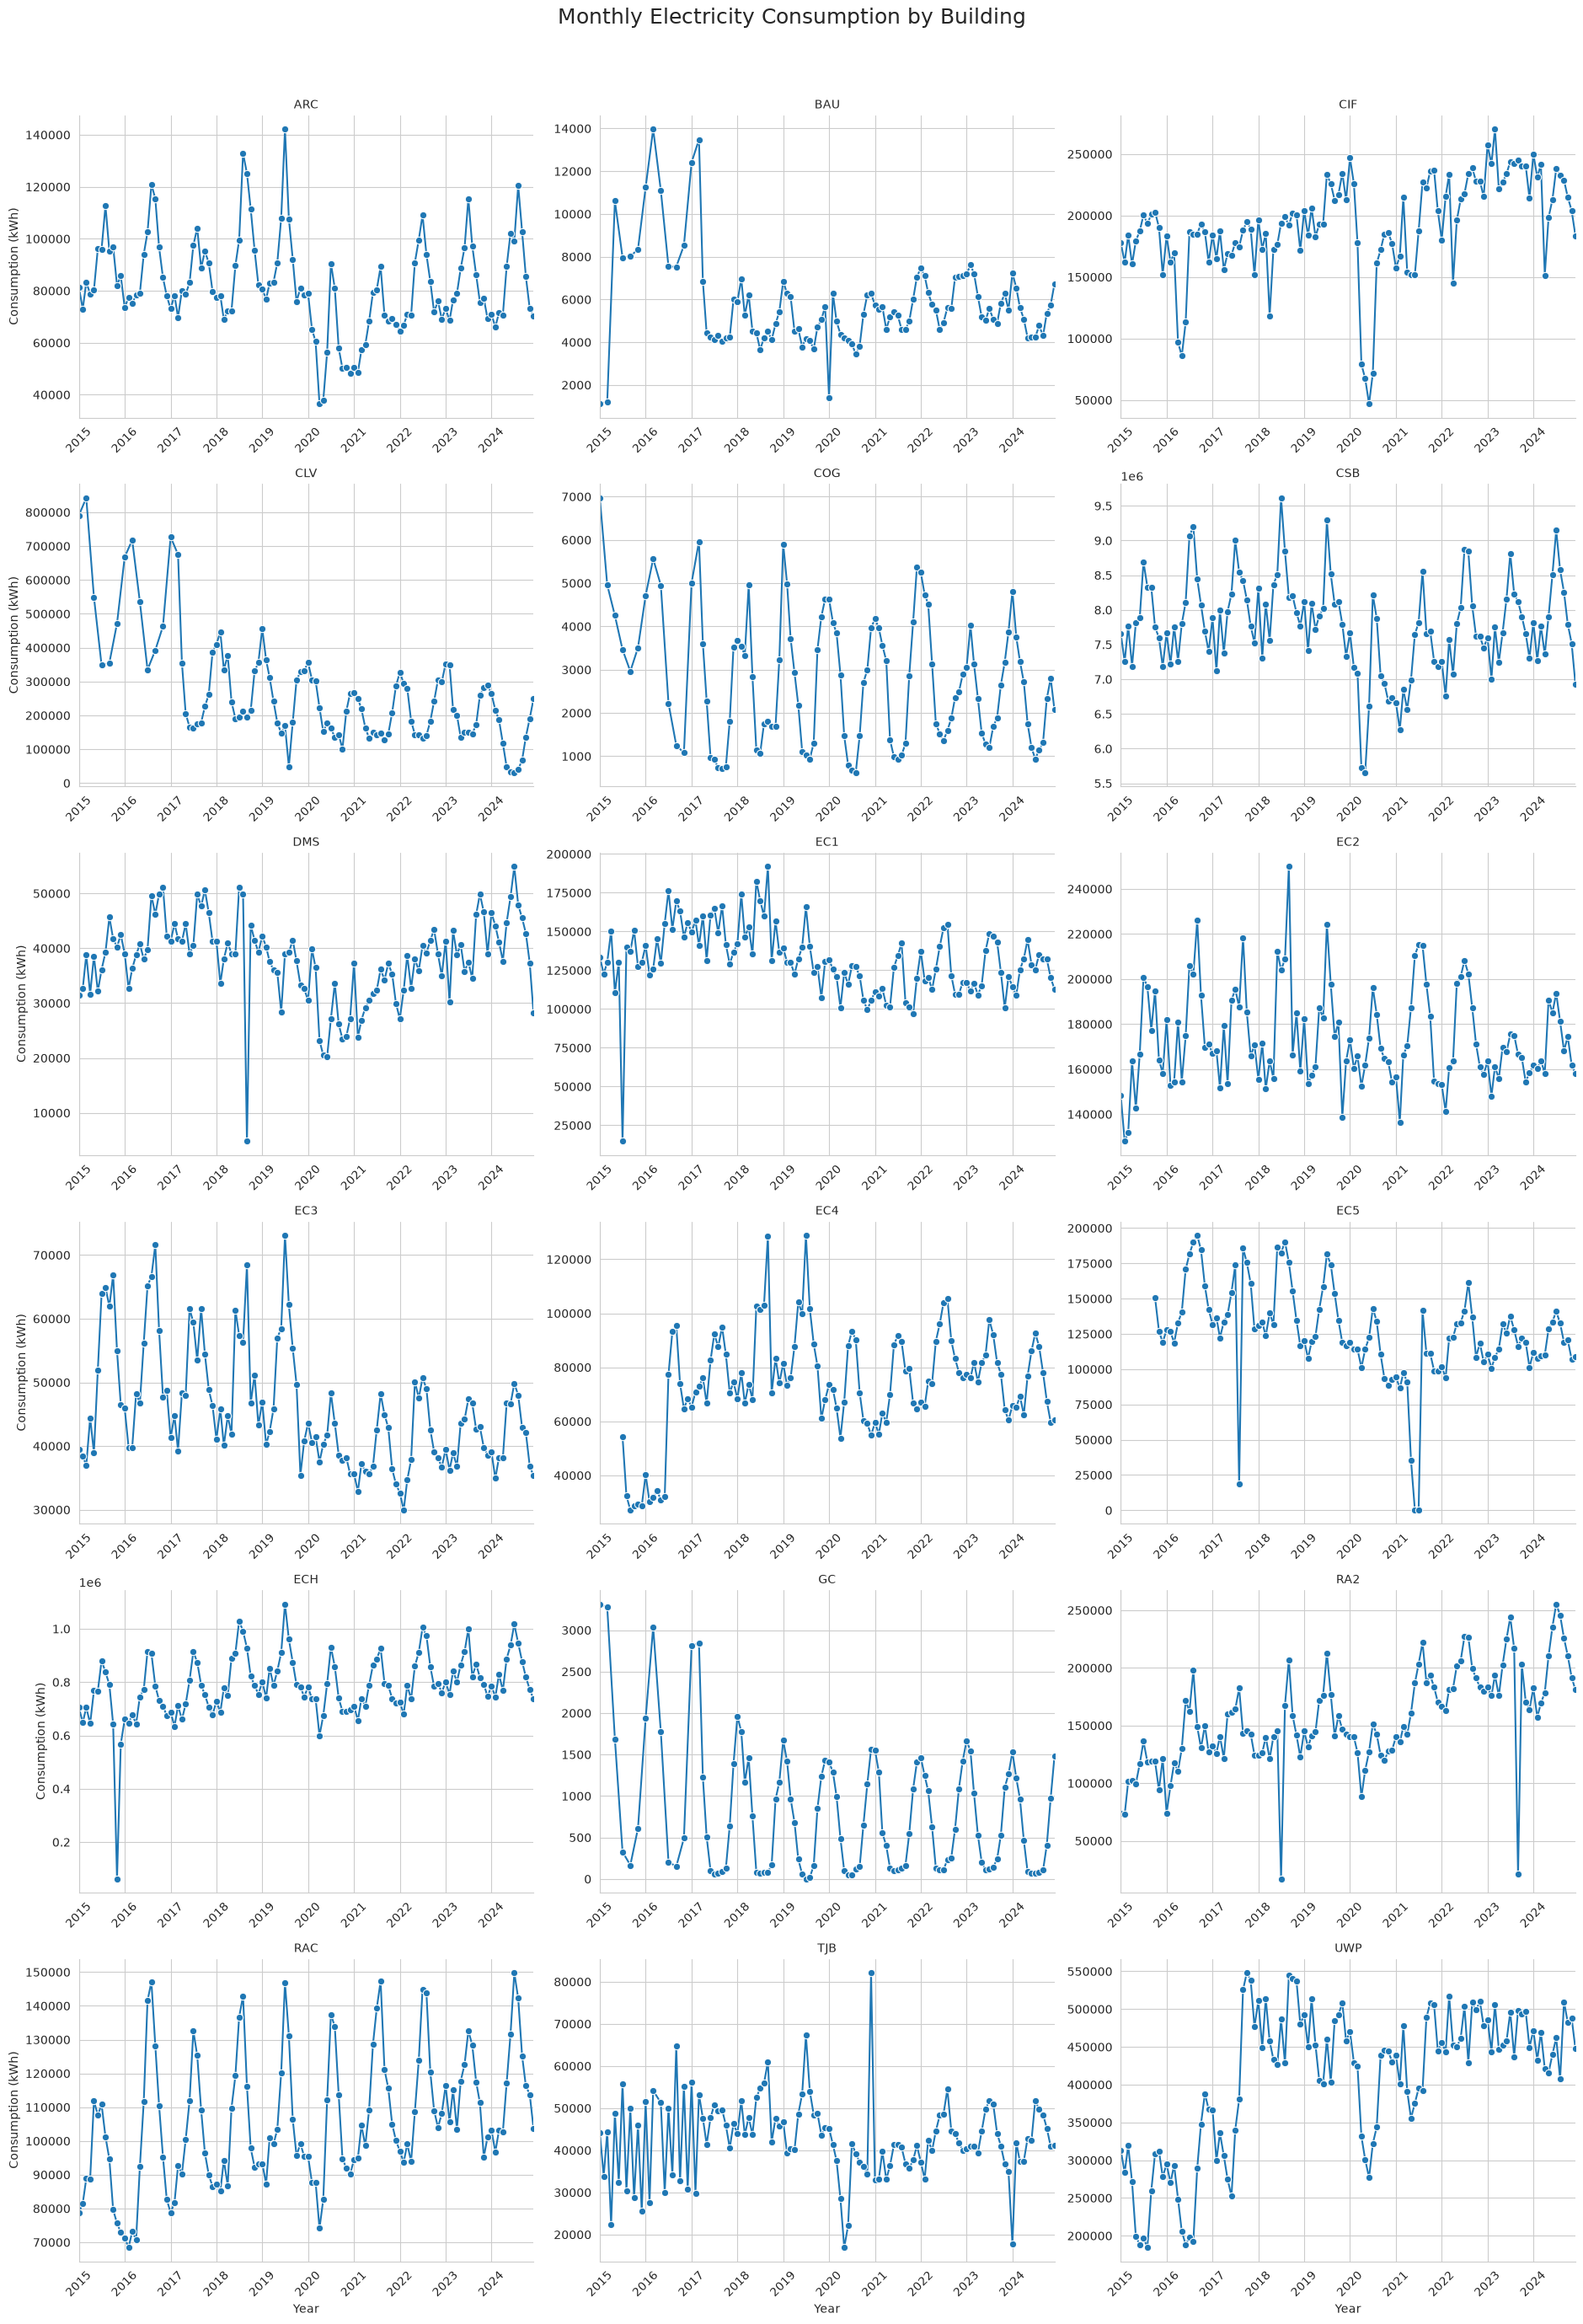

In [6]:
# Consumption per building over time
electricity['Start Date'] = pd.to_datetime(electricity['Start Date'])
g = sns.FacetGrid(
    electricity,
    col='Building Code',
    col_wrap=3,
    height=4.5,
    aspect=1.4,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='Start Date',
    y='Consumption',
    marker='o',
    errorbar=None
)

g.set_titles('{col_name}')
g.set_axis_labels('Year', 'Consumption (kWh)')
g.fig.suptitle('Monthly Electricity Consumption by Building', fontsize=18, y=1.02)

# Get unique years and first date of each year
years = sorted(electricity['Start Date'].dt.year.unique())
tick_positions = (
    electricity
    .groupby(electricity['Start Date'].dt.year)['Start Date']
    .min()
    .sort_values()
)

# Set x-axis ticks, labels, and limits for all subplots
start_date = electricity['Start Date'].min()
end_date = electricity['Start Date'].max()

for ax in g.axes.flat:
    ax.set_xlim(start_date, end_date)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(years, rotation=45)
    ax.tick_params(axis='x', labelbottom=True)

plt.tight_layout()
plt.show()

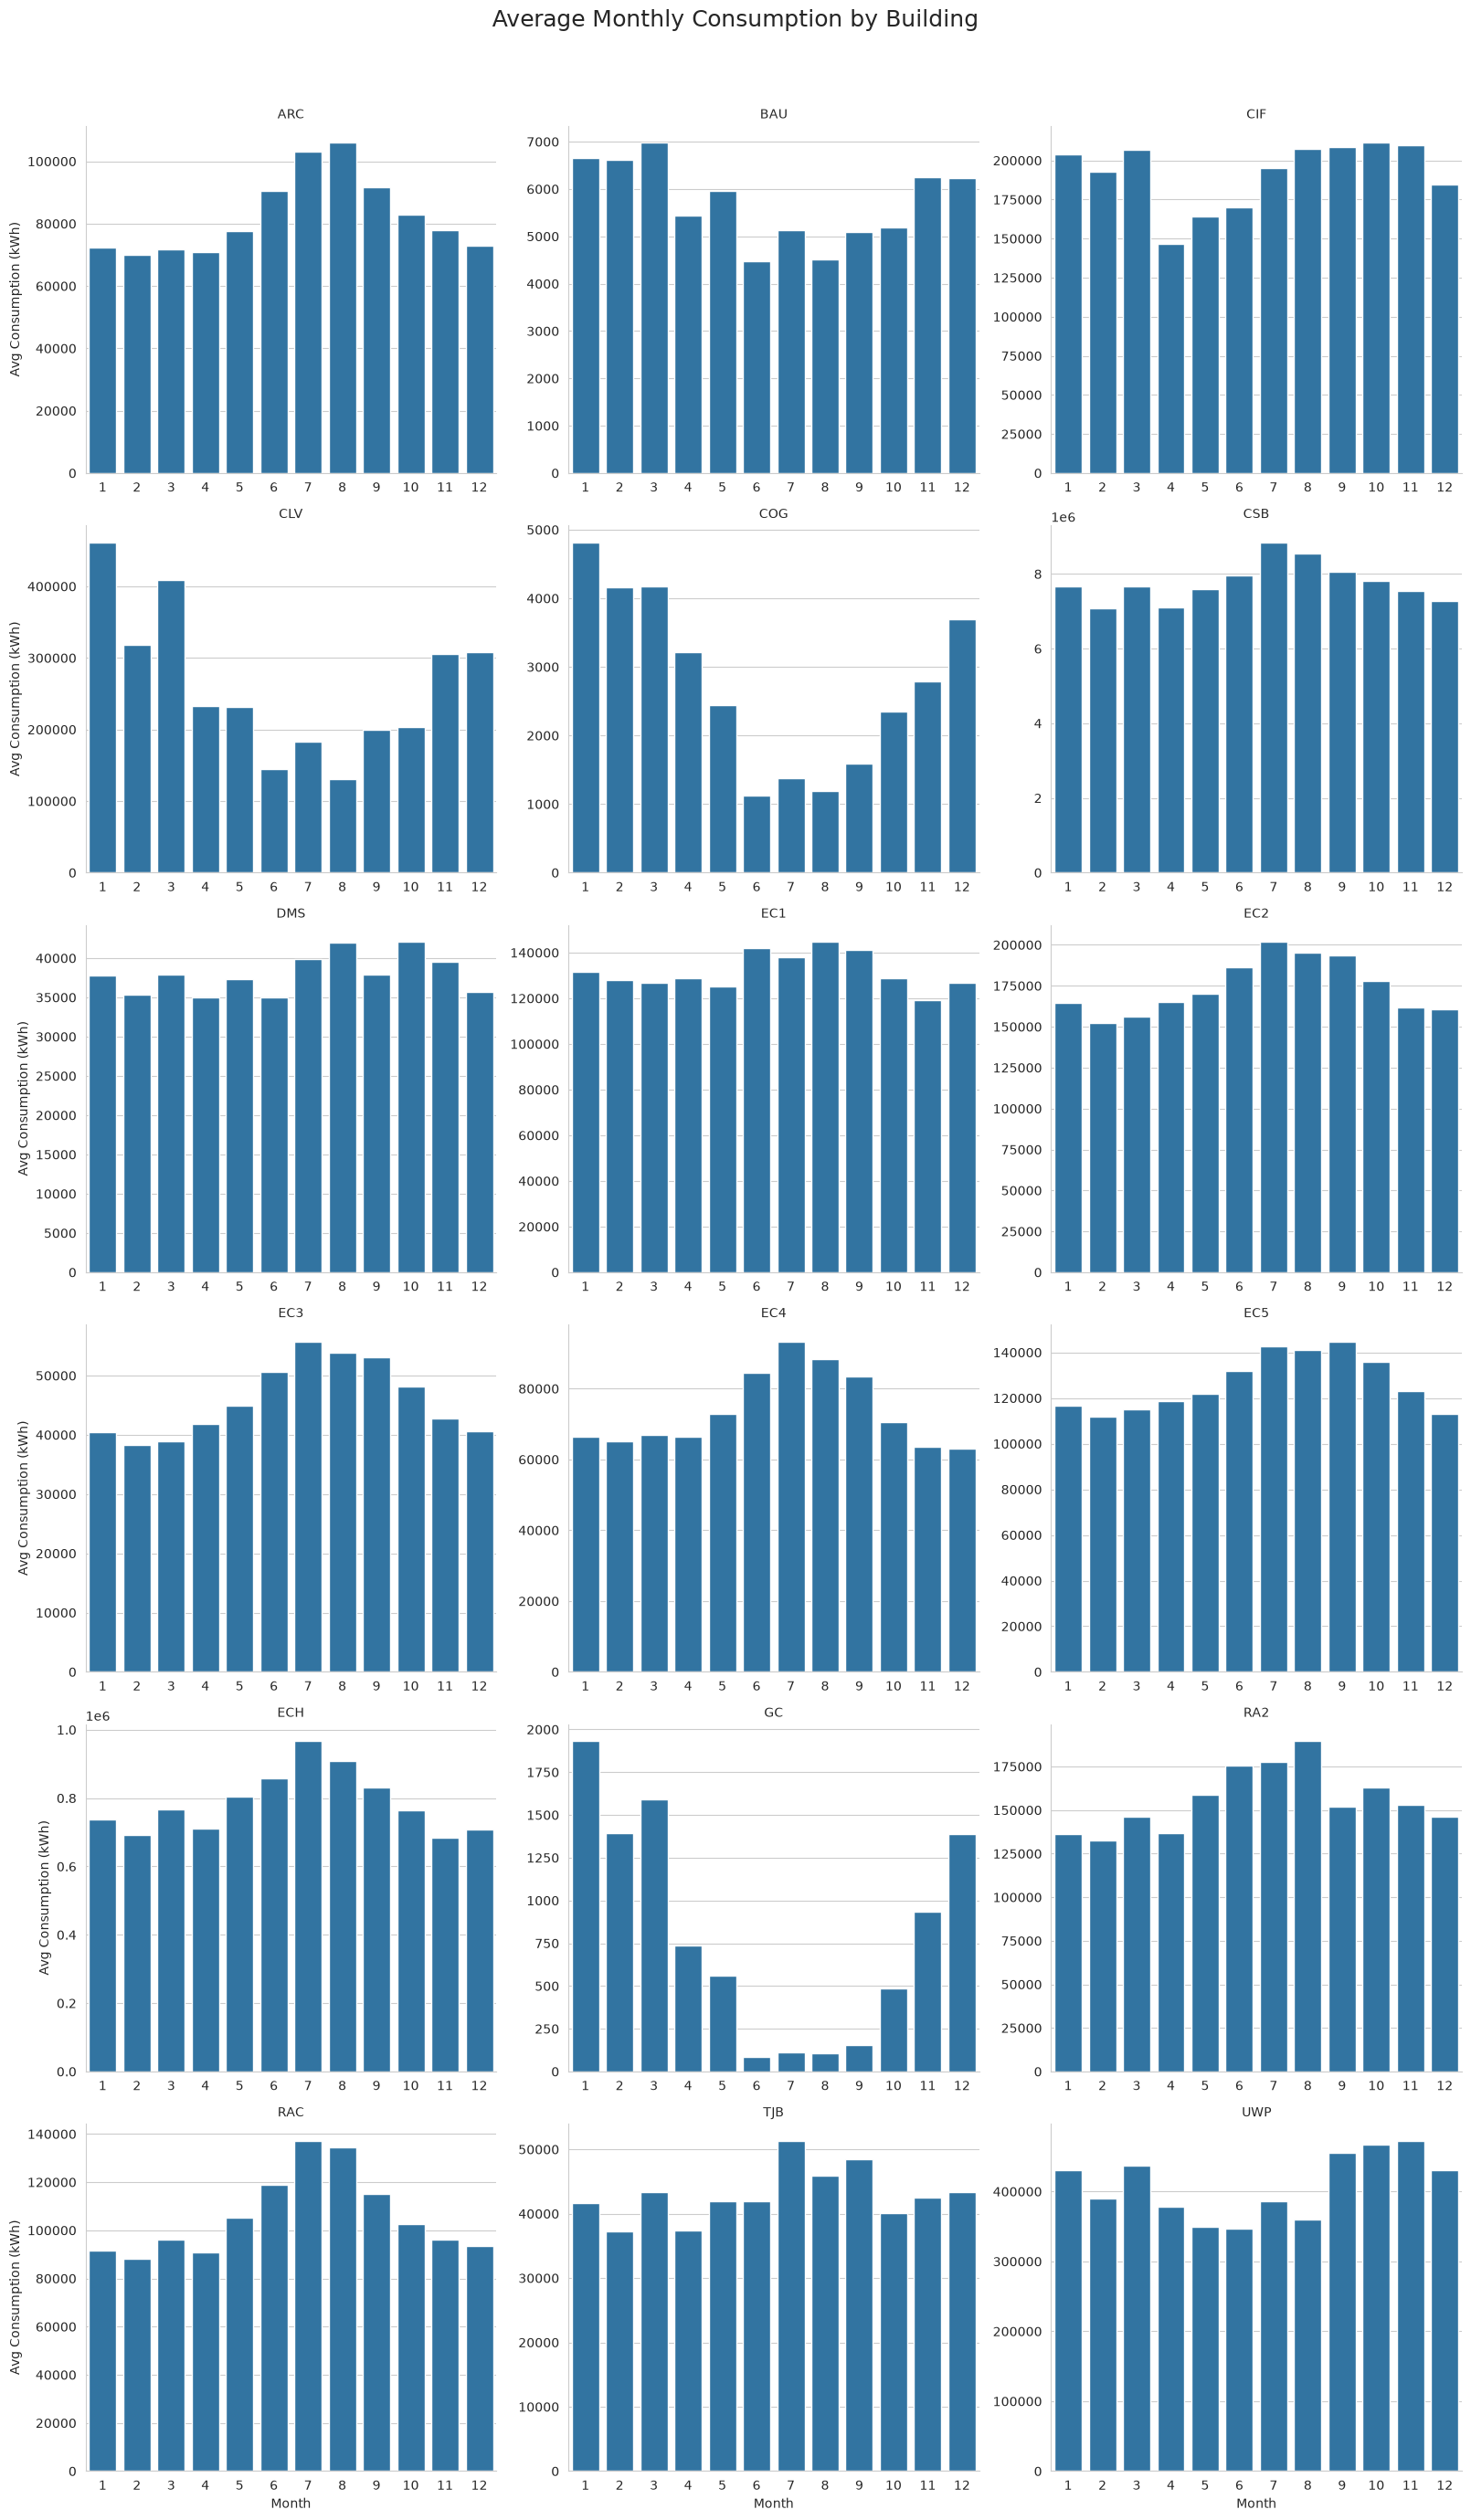

In [7]:
# Average consumption per month for each building
avg_monthly = electricity.groupby(['Building Code', 'Month'])['Consumption'].mean().reset_index()

g = sns.FacetGrid(
    avg_monthly,
    col='Building Code',
    col_wrap=3,
    height=4.5,
    aspect=1.2,
    sharey=False
)
g.map_dataframe(sns.barplot, x='Month', y='Consumption', errorbar=None)
g.set_titles('{col_name}')
g.set_axis_labels('Month', 'Avg Consumption (kWh)')
g.fig.suptitle('Average Monthly Consumption by Building', fontsize=18, y=1.02)

# Set x-axis ticks and labels for all plots
for ax in g.axes.flatten():
    ax.set_xticks(range(0, 12))       # positions (0–11)
    ax.set_xticklabels(range(1, 13))  # labels (1–12)
    ax.tick_params(axis='x', labelbottom=True)  # force labels on all facets

plt.tight_layout()
plt.show()

Correlation between monthly electricity consumption and temperature: 0.449


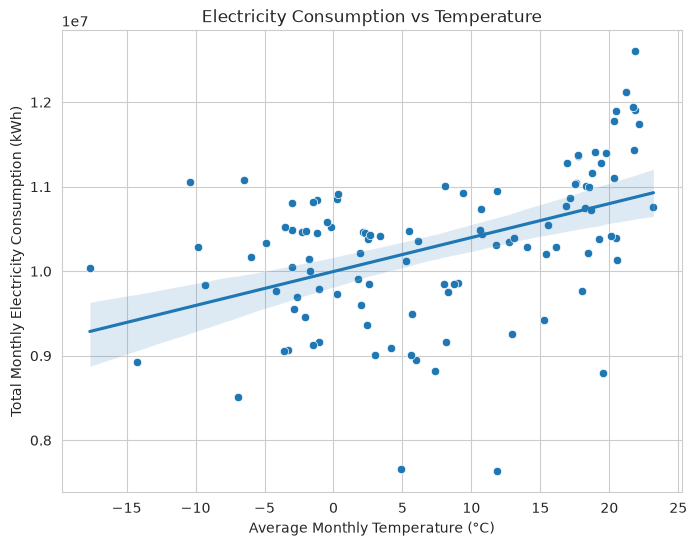

In [8]:
# Correlation between electricity consumption and temperature
weather['DateTime'] = pd.to_datetime(weather[['Year','Month','Day','Hour']])
weather = weather.set_index('DateTime')
electricity['YearMonth'] = electricity['Start Date'].dt.to_period('M').dt.to_timestamp()

# Monthly average temperature
monthly_temp = weather['Temperature'].resample('ME').mean()
monthly_temp_df = monthly_temp.reset_index()
monthly_temp_df.rename(columns={'Temperature':'AvgTemp'}, inplace=True)
monthly_temp_df['YearMonth'] = monthly_temp_df['DateTime'].dt.to_period('M').dt.to_timestamp()
monthly_consumption = electricity.groupby('YearMonth')['Consumption'].sum().reset_index()

# Merge data
consumption_temp = pd.merge(
    monthly_consumption,
    monthly_temp_df[['YearMonth','AvgTemp']],
    on='YearMonth',
    how='inner'
)

# Correlation
corr = consumption_temp['Consumption'].corr(consumption_temp['AvgTemp'])
print(f"Correlation between monthly electricity consumption and temperature: {corr:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=consumption_temp,
    x='AvgTemp',
    y='Consumption'
)
sns.regplot(
    data=consumption_temp,
    x='AvgTemp',
    y='Consumption',
    scatter=False
)

plt.xlabel('Average Monthly Temperature (°C)')
plt.ylabel('Total Monthly Electricity Consumption (kWh)')
plt.title('Electricity Consumption vs Temperature')
plt.show()